In [ ]:
import os
from scipy import stats
import sqlalchemy
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
caminho = os.path.abspath('../../../../data')

In [3]:

engine = sqlalchemy.create_engine("sqlite:///" + os.path.join(caminho, 'booking_db.sqlite'))

In [4]:
# tabela ABT para todas as analises
abt = pd.read_sql_table('tb_abt_churn', engine)


df_oot = abt[abt['ref_date'] == abt['ref_date'].max()].copy() # filtrando base out of time

df_abt = abt[abt['ref_date'] < abt['ref_date'].max()].copy() # filtrando base ABT

In [5]:
df_abt.head()

,ref_date,review_date,review_id,user_id,hotel_name,city,country,ultima_review,freq_total_reviews,freq_reviews_ultimos_90_dias,...,div_hoteis_diferentes,div_cidades_diferentes,div_media_estrelas_hoteis,media_custo_beneficio,temp_dias_desde_primeira_review,user_gender,age_group,traveller_type,review_text,target_churn
0,2020-12-31,2020-03-24,2,432,Kyo-to Grand,Tokyo,Japan,131.0,6,0,...,6,6,5.0,8.6000,282.0,Female,35-44,Couple,Fly long television early south range. Join le...,0
1,2020-12-31,2020-05-15,11,71,The Gateway Royale,Mumbai,India,23.0,7,1,...,6,6,5.0,8.7000,230.0,Male,25-34,Couple,Very buy everything claim government. Agree no...,0
2,2020-12-31,2020-02-28,64,37,The Bosphorus Inn,Istanbul,Turkey,26.0,6,3,...,4,4,5.0,8.5500,307.0,Male,18-24,Couple,Traditional everybody though store deal. Ball ...,0
3,2020-12-31,2020-03-23,98,1560,The Royal Compass,London,United Kingdom,24.0,5,1,...,3,3,5.0,8.1000,283.0,Female,25-34,Business,Nor poor major that. You institution board doo...,0
4,2020-12-31,2020-06-04,116,1746,The Gateway Royale,Mumbai,India,63.0,8,2,...,7,7,5.0,8.4125,210.0,Male,25-34,Business,Relationship amount as plan culture stage. Tra...,0


In [6]:
df_abt.drop(['ref_date', 'review_id', 'user_id'],axis=1, inplace=True )

In [36]:
df_abt.info()

<class 'pandas.DataFrame'>
RangeIndex: 9866 entries, 0 to 9865
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   review_date                      9866 non-null   datetime64[us]
 1   hotel_name                       9866 non-null   str           
 2   city                             9866 non-null   str           
 3   country                          9866 non-null   str           
 4   ultima_review                    9866 non-null   float64       
 5   freq_total_reviews               9866 non-null   int64         
 6   freq_reviews_ultimos_90_dias     9866 non-null   int64         
 7   freq_reviews_ultimos_180_dias    9866 non-null   int64         
 8   freq_reviews_ultimos_365_dias    9866 non-null   int64         
 9   sat_media_score_overall          9866 non-null   float64       
 10  sat_media_score_limpeza          9866 non-null   float64       
 11  sa

In [35]:
# Converte a coluna para datetime
df_abt['review_date'] = pd.to_datetime(df_abt['review_date'], format='%Y-%m-%d')

In [37]:
df_abt.isnull().sum()

review_date                        0
hotel_name                         0
city                               0
country                            0
ultima_review                      0
freq_total_reviews                 0
freq_reviews_ultimos_90_dias       0
freq_reviews_ultimos_180_dias      0
freq_reviews_ultimos_365_dias      0
sat_media_score_overall            0
sat_media_score_limpeza            0
sat_media_score_conforto           0
sat_media_score_comodidades        0
div_hoteis_diferentes              0
div_cidades_diferentes             0
div_media_estrelas_hoteis          0
media_custo_beneficio              0
temp_dias_desde_primeira_review    0
user_gender                        0
age_group                          0
traveller_type                     0
review_text                        0
target_churn                       0
sentimento_review                  0
dtype: int64

In [38]:
df_abt.describe()

,review_date,ultima_review,freq_total_reviews,freq_reviews_ultimos_90_dias,freq_reviews_ultimos_180_dias,freq_reviews_ultimos_365_dias,sat_media_score_overall,sat_media_score_limpeza,sat_media_score_conforto,sat_media_score_comodidades,div_hoteis_diferentes,div_cidades_diferentes,div_media_estrelas_hoteis,media_custo_beneficio,temp_dias_desde_primeira_review,target_churn,sentimento_review
count,9866,9866.000000,9866.000000,9866.000000,9866.000000,9866.000000,9866.000000,9866.000000,9866.000000,9866.000000,9866.000000,9866.000000,9866.0,9866.000000,9866.000000,9866.000000,9866.000000
mean,2022-03-30 08:42:40.064869,93.396817,4.215082,0.775492,2.006284,4.215082,8.944316,9.055675,9.026615,8.741970,3.891040,3.891040,5.0,8.512197,276.059193,0.013379,0.239510
min,2020-01-01 00:00:00,1.000000,1.000000,0.000000,0.000000,1.000000,8.300000,7.700000,8.000000,7.600000,1.000000,1.000000,5.0,7.900000,1.000000,0.000000,-0.921800
25%,2021-02-01 00:00:00,31.000000,3.000000,0.000000,1.000000,3.000000,8.866667,8.680000,8.775000,8.400000,3.000000,3.000000,5.0,8.425000,237.000000,0.000000,0.000000
50%,2022-03-18 00:00:00,81.000000,4.000000,1.000000,2.000000,4.000000,8.950000,9.200000,9.000000,8.700000,4.000000,4.000000,5.0,8.520000,290.000000,0.000000,0.275050
75%,2023-05-08 00:00:00,139.000000,5.000000,1.000000,3.000000,5.000000,9.025000,9.400000,9.288542,9.066667,5.000000,5.000000,5.0,8.600000,331.000000,0.000000,0.572650
max,2024-12-24 00:00:00,365.000000,17.000000,6.000000,8.000000,17.000000,9.500000,10.000000,10.000000,10.000000,12.000000,12.000000,5.0,8.900000,365.000000,1.000000,0.975300
std,NaN,72.125184,1.983244,0.871449,1.391510,1.983244,0.120466,0.423489,0.321700,0.407300,1.751977,1.751977,0.0,0.142856,69.407174,0.114898,0.406309


In [51]:
# Baixa o dicionário de regras do VADER (focado em avaliações/sentimentos)
# nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()


# 1. Tratamento dos nulos
df_abt['review_text'] = df_abt['review_text'].fillna("")

# TRATAMENTO E EXTRAÇÃO DE SENTIMENTO
def extrair_sentimento(texto):
    if str(texto).strip() == "":
        return 0.0 # Texto vazio recebe score neutro
    
    scores = sia.polarity_scores(str(texto))
    return scores['compound'] # Retorna a nota geral de sentimento (-1 a +1)

print("Extraindo o sentimento dos textos...")
# Aplica a função em toda a base abt
df_abt['sentimento_review'] = df_abt['review_text'].apply(extrair_sentimento)


Extraindo o sentimento dos textos...


In [52]:
# Separando as variáveis categóricas
variaveis_categoricas = []
for i in df_abt.columns[0:22].tolist():
        if df_abt.dtypes[i] == 'object' or df_abt.dtypes[i] == 'str':
            variaveis_categoricas.append(i)

In [42]:
variaveis_numericas = list(set(df_abt.columns) - set(variaveis_categoricas))

In [43]:
target = 'target_churn'
resultados = []


# VARIÁVEIS NUMÉRICAS (Teste U de Mann-Whitney)

for col in variaveis_numericas:
    # Separamos os dois grupos baseados no Churn (0 ou 1)
    grupo_0 = df_abt[df_abt[target] == 0][col].dropna()
    grupo_1 = df_abt[df_abt[target] == 1][col].dropna()
    
    # Garantimos que ambos os grupos possuem dados para testar
    if len(grupo_0) > 0 and len(grupo_1) > 0:
        # Aplicamos o teste não-paramétrico de Mann-Whitney
        stat, p_val = stats.mannwhitneyu(grupo_0, grupo_1, alternative='two-sided')
        
        # Guardamos o resultado
        resultados.append({
            'Variavel': col,
            'Tipo': 'Numérica',
            'Teste Aplicado': 'Mann-Whitney U',
            'P-Valor': p_val,
            'Significativo (95%)': 'Sim' if p_val < 0.05 else 'Não'
        })


# VARIÁVEIS CATEGÓRICAS (Teste Qui-Quadrado)

for col in variaveis_categoricas:
    # Criamos a tabela de contingência cruzando a categoria com o Churn
    tabela_contingencia = pd.crosstab(df_abt[col], df_abt[target])
    
    # O teste exige que a tabela não esteja vazia
    if not tabela_contingencia.empty:
        # Aplicamos o teste Qui-Quadrado
        chi2, p_val, dof, expected = stats.chi2_contingency(tabela_contingencia)
        
        # Guardamos o resultado
        resultados.append({
            'Variavel': col,
            'Tipo': 'Categórica',
            'Teste Aplicado': 'Qui-Quadrado',
            'P-Valor': p_val,
            'Significativo (95%)': 'Sim' if p_val < 0.05 else 'Não'
        })


# CRIAÇÃO DO RELATÓRIO FINAL

df_relatorio = pd.DataFrame(resultados)

# Ordena deixando as variáveis mais importantes (menor p-valor) no topo
df_relatorio = df_relatorio.sort_values(by='P-Valor').reset_index(drop=True)

# Exibe a tabela final completa
print(df_relatorio)



                           Variavel        Tipo  Teste Aplicado       P-Valor  \
0                      target_churn    Numérica  Mann-Whitney U  0.000000e+00   
1                 sentimento_review    Numérica  Mann-Whitney U  5.176493e-17   
2           sat_media_score_overall    Numérica  Mann-Whitney U  2.555626e-02   
3       sat_media_score_comodidades    Numérica  Mann-Whitney U  1.251477e-01   
4                       review_text  Categórica    Qui-Quadrado  1.719269e-01   
5                       review_date    Numérica  Mann-Whitney U  1.894423e-01   
6                     ultima_review    Numérica  Mann-Whitney U  2.247130e-01   
7                       user_gender  Categórica    Qui-Quadrado  2.707195e-01   
8     freq_reviews_ultimos_365_dias    Numérica  Mann-Whitney U  2.720809e-01   
9                freq_total_reviews    Numérica  Mann-Whitney U  2.720809e-01   
10    freq_reviews_ultimos_180_dias    Numérica  Mann-Whitney U  3.730570e-01   
11            media_custo_be

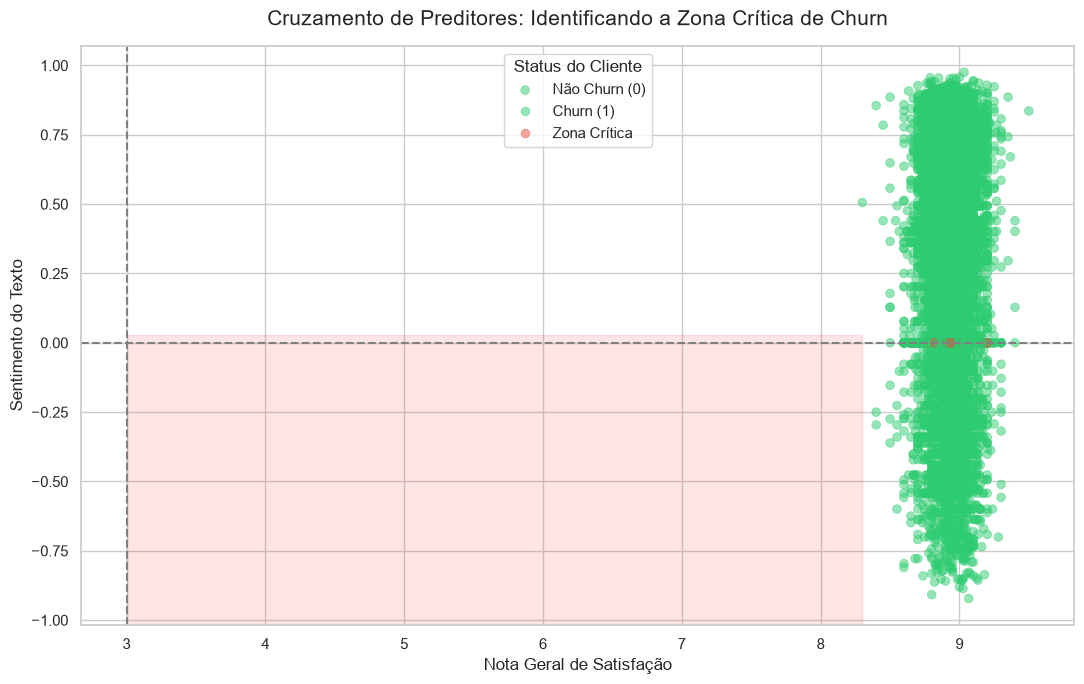

In [54]:
# Configura o estilo do gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 7))

# Criando o gráfico de dispersão
sns.scatterplot(
    data=df_abt,
    x='sat_media_score_overall',
    y='sentimento_review',
    hue='target_churn',
    palette={0: '#2ecc71', 1: '#e74c3c'}, # Verde para Não Churn, Vermelho para Churn
    alpha=0.5,                            # Transparência para ver a densidade dos pontos
    edgecolor=None,                       # Remove a borda dos pontos para suavizar
    s=40                                  # Tamanho dos pontos
)

# --- MAPEANDO A ZONA CRÍTICA (LINHAS GUIAS) ---
# Linha vertical na nota de satisfação média de corte (ex: nota 3.0)
plt.axvline(x=3.0, color='gray', linestyle='--', linewidth=1.5)

# Linha horizontal no sentimento neutro (0.0)
plt.axhline(y=0.0, color='gray', linestyle='--', linewidth=1.5)

# Adicionando um sombreamento vermelho na "Zona Crítica de Churn"
# (Canto inferior esquerdo: Satisfação < 3 e Sentimento < 0)
plt.axvspan(xmin=df_abt['sat_media_score_overall'].min(), xmax=3.0, 
            ymin=0.0, ymax=0.5, # Ajuste proporcional na escala do eixo Y (0.5 é o meio do gráfico)
            color='red', alpha=0.1, label='Zona Crítica de Churn')

# Customização de títulos e eixos
plt.title("Cruzamento de Preditores: Identificando a Zona Crítica de Churn", fontsize=15, pad=15)
plt.xlabel("Nota Geral de Satisfação", fontsize=12)
plt.ylabel("Sentimento do Texto", fontsize=12)

# Ajustando as legendas
plt.legend(title="Status do Cliente", labels=["Não Churn (0)", "Churn (1)", "Zona Crítica"])

plt.tight_layout()
plt.show()


In [47]:
df_abt['target_churn'].mean()*100

np.float64(1.3379282383944862)

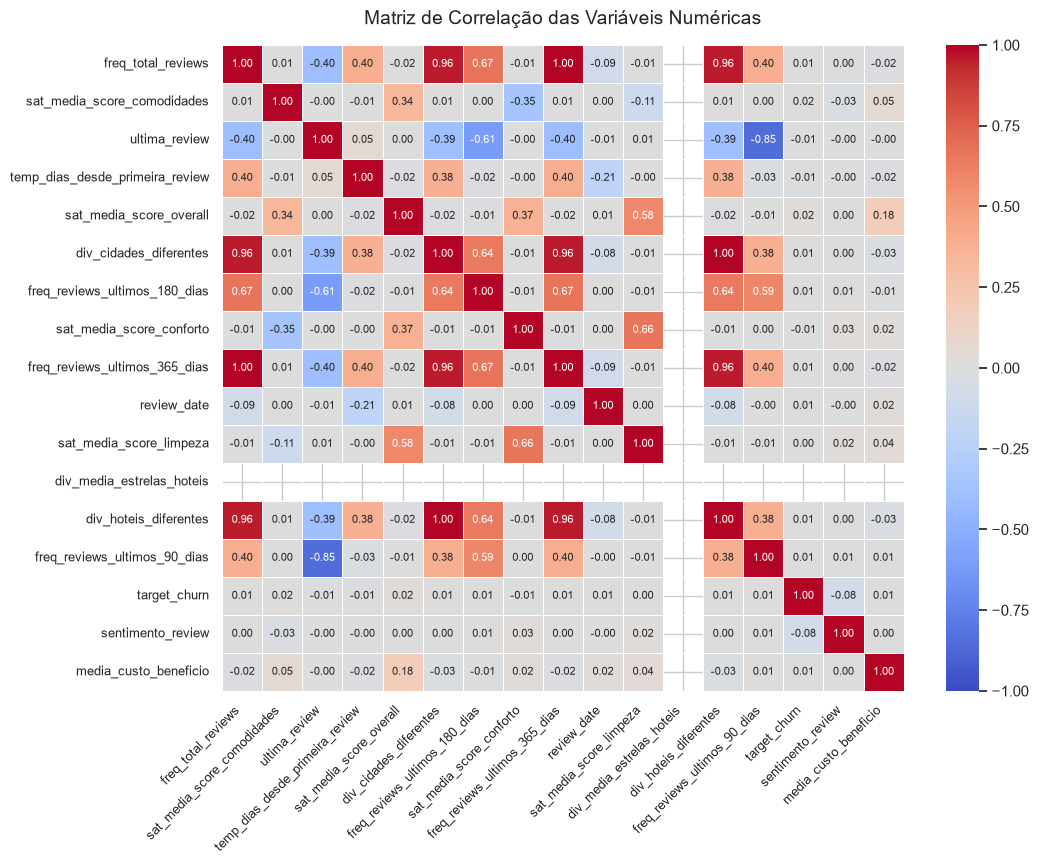

In [48]:
# Filtramos o DataFrame e removemos colunas com erro (como a 'div_media_estrelas_hoteis' que deu NaN)
df_mapa = df_abt[variaveis_numericas].dropna(how='all', axis=1)

# Calculamos a matriz de correlação de Spearman
matriz_corr = df_mapa.corr(method='spearman')

#  Configura o tamanho do gráfico para ficar proporcional ao número de variáveis da sua lista
tamanho = max(11, len(variaveis_numericas) * 0.6)
plt.figure(figsize=(tamanho, tamanho * 0.8))

# Desenhamos o mapa de calor com o Seaborn
sns.heatmap(
    matriz_corr, 
    annot=True,          # Mostra os valores de correlação dentro dos quadrados
    cmap='coolwarm',     # Azul (negativo), Branco (neutro), Vermelho (positivo)
    fmt=".2f",           # Exibe com 2 casas decimais
    vmin=-1, vmax=1,     # Define os limites padrão de correlação
    linewidths=0.5,      # Linha fina de separação entre os blocos
    annot_kws={"size": 8} # Ajusta o tamanho da fonte para não cortar os números
)

plt.title("Matriz de Correlação das Variáveis Numéricas", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.show()

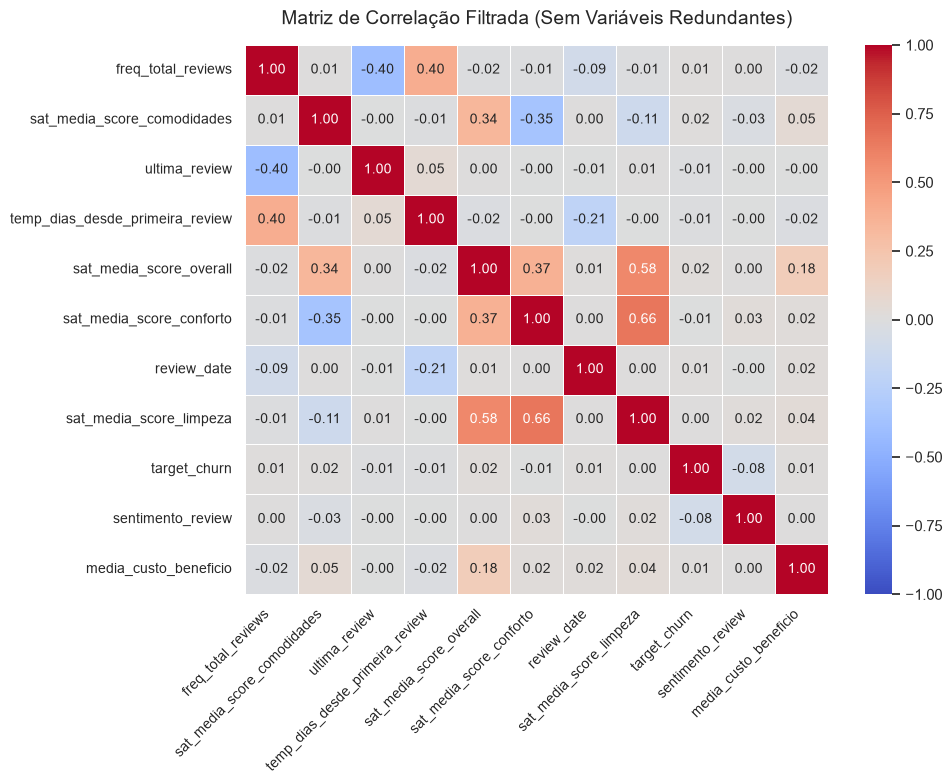

In [ ]:
# 1. Definimos a lista de variáveis que vamos REMOVER (redundantes e vazias)
variaveis_para_remover = [
    'freq_reviews_ultimos_365_dias',  # Redundante com freq_total_reviews (1.00)
    'div_cidades_diferentes',         # Redundante com freq_total_reviews (0.96)
    'div_hoteis_diferentes',          # Redundante com freq_total_reviews (0.96)
    'freq_reviews_ultimos_180_dias',  # Alta correlação com as outras frequências
    'freq_reviews_ultimos_90_dias',   # Altamente correlacionada negativamente com ultima_review (-0.85)
    'div_media_estrelas_hoteis'       # Coluna completamente vazia (NaN)
]

# Criamos uma nova lista mantendo apenas as variáveis numéricas limpas e relevantes
# (Usando a sua lista original 'variaveis_numericas')
variaveis_focadas = [col for col in variaveis_numericas if col not in variaveis_para_remover]

# Garantimos que os nossos dois pilares fundamentais e o target estejam na lista
for coluna_essencial in ['sat_media_score_overall', 'sentimento_review', 'target_churn']:
    if coluna_essencial not in list(variaveis_focadas):
        variaveis_focadas.append(coluna_essencial)

# Filtramos o DataFrame principal criando uma versão compacta para o mapa
df_focado = df_abt[variaveis_focadas].dropna(how='all', axis=1)

# Calculamos a nova matriz de correlação de Spearman
matriz_focada = df_focado.corr(method='spearman')

# Desenhamos o novo mapa de calor filtrado
plt.figure(figsize=(10, 8))

sns.heatmap(
    matriz_focada, 
    annot=True,          # Mostra os valores de correlação
    cmap='coolwarm',     # Escala visual padrão (Azul/Vermelho)
    fmt=".2f",           # 2 casas decimais
    vmin=-1, vmax=1,     # Limites fixos de correlação
    linewidths=0.5,      # Linha de separação dos blocos
    annot_kws={"size": 10}
)

plt.title("Matriz de Correlação Filtrada (Sem Variáveis Redundantes)", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()


=== TAXA DE CHURN POR CATEGORIA (Média da Base: 1.33%) ===

Distribuição para a variável user_gender:
user_gender  target_churn
      Other      1.569038
     Female      1.500938
       Male      1.140766


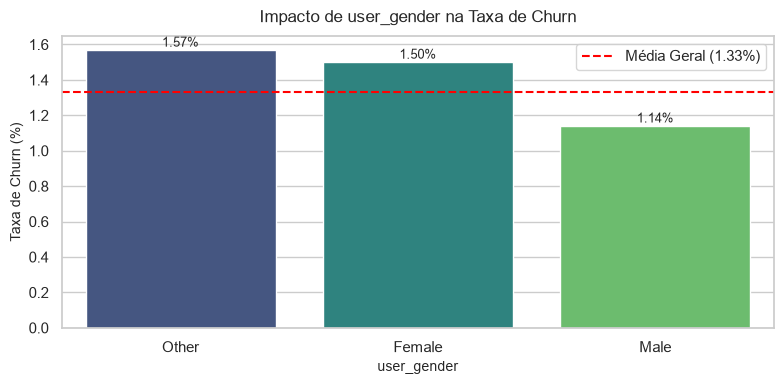


Distribuição para a variável age_group:
age_group  target_churn
      55+      1.616162
    25-34      1.368585
    18-24      1.301115
    35-44      1.291818
    45-54      1.213282


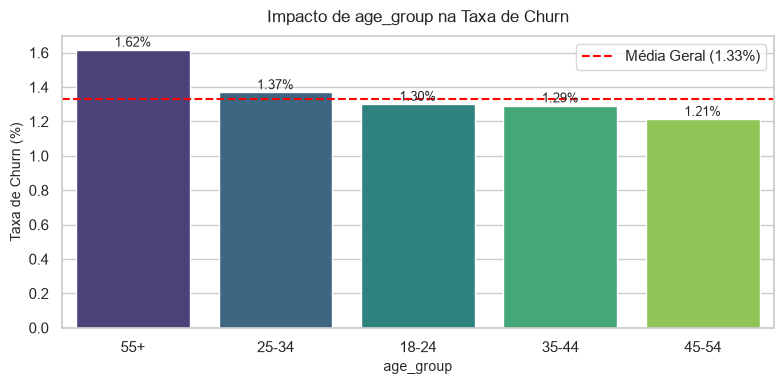


Distribuição para a variável traveller_type:
traveller_type  target_churn
          Solo      1.546641
        Family      1.313003
      Business      1.290963
        Couple      1.256575


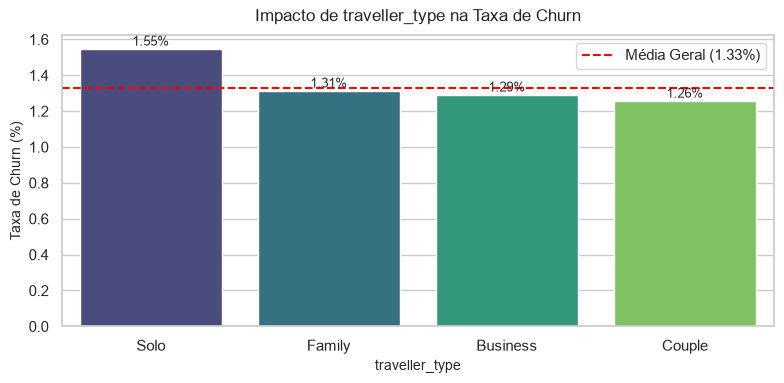

In [50]:
# Configura o estilo visual do Seaborn
sns.set_theme(style="whitegrid")

# Lista das suas variáveis categóricas de perfil
categorias_perfil = ['user_gender', 'age_group', 'traveller_type']

print("=== TAXA DE CHURN POR CATEGORIA (Média da Base: 1.33%) ===")

# Loop para analisar cada variável categórica
for col in categorias_perfil:
    # 1. Calcula a porcentagem real de churn dentro de cada grupo
    tabela_proporcao = df_abt.groupby(col)['target_churn'].mean().reset_index()
    tabela_proporcao['target_churn'] = tabela_proporcao['target_churn'] * 100 # Converte para %
    
    # Ordena para o gráfico ficar mais bonito
    tabela_proporcao = tabela_proporcao.sort_values(by='target_churn', ascending=False)
    
    print(f"\nDistribuição para a variável {col}:")
    print(tabela_proporcao.to_string(index=False))
    
    # 2. Plota o gráfico de barras atualizado com as novas regras do Seaborn
    plt.figure(figsize=(8, 4))
    ax = sns.barplot(
        data=tabela_proporcao,
        x=col,
        y='target_churn',
        hue=col,            # Ajuste aqui: define o hue igual ao eixo x
        legend=False,       # Ajuste aqui: remove a legenda repetida
        palette="viridis"
    )
    
    # Adiciona uma linha guia mostrando a média geral de churn da base (1.33%)
    plt.axhline(y=1.33, color='red', linestyle='--', linewidth=1.5, label='Média Geral (1.33%)')
    
    # Customizações do gráfico
    plt.title(f"Impacto de {col} na Taxa de Churn", fontsize=12, pad=10)
    plt.xlabel(col, fontsize=10)
    plt.ylabel("Taxa de Churn (%)", fontsize=10)
    plt.legend()
    
    # Adiciona os valores em cima de cada barra
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}%", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 5), 
                    textcoords='offset points', fontsize=9)
        
    plt.tight_layout()
    plt.show()
